Dataset: 891 rows x 15 columns


,missing_count,missing_pct
deck,688,77.2
Age,177,19.9
Embarked,2,0.2
embark_town,2,0.2


LabelEncoder classes: ['did_not_survive' 'survived'] | sample: [1 0 0 1 1]
OneHotEncoder columns: ['Sex_female', 'Sex_male', 'Embarked_C', 'Embarked_Missing', 'Embarked_Q', 'Embarked_S'] | shape: (712, 6)
OrdinalEncoder Pclass sample: [2. 1. 0. 2. 1.]
Leakage-safe transformed shapes: (712, 10) (179, 10)


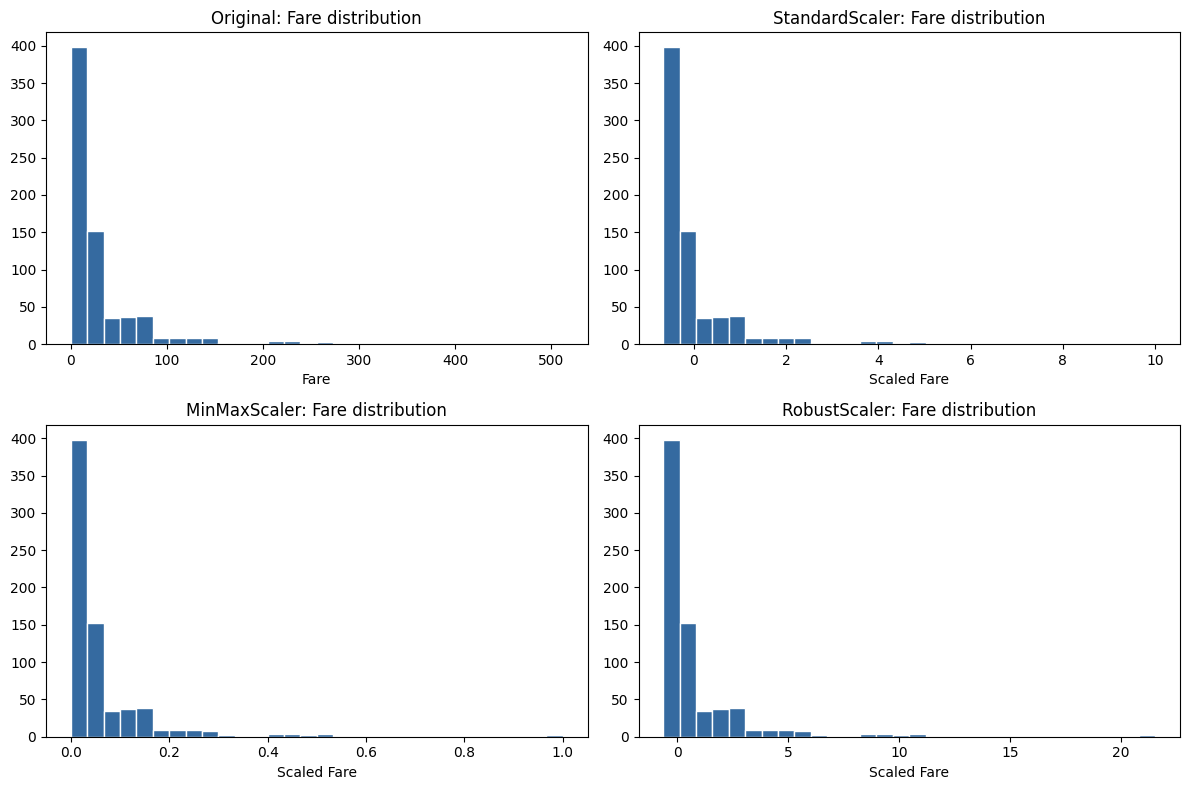

,Scaler,Mean,Std,Median,Min,Max
0,Original,31.820,48.025,14.454,0.000,512.329
1,StandardScaler,-0.000,1.000,-0.362,-0.663,10.005
2,MinMaxScaler,0.062,0.094,0.028,0.000,1.000
3,RobustScaler,0.752,2.079,0.000,-0.626,21.549


,Feature,F-Score,Why it matters
0,Sex_male,306.593249,Sex was strongly associated with evacuation pr...
1,Pclass,97.835853,Class influenced cabin location and access to ...
2,Fare,58.314907,Ticket fare proxies passenger class and access...
3,Embarked_S,25.604257,This feature has a strong individual statistic...
4,parch,5.066904,Parents/children aboard captures family travel...


MLflow is not installed; evidence saved locally: W2D2_run_summary.json, W2D2_top5_features.csv, W2D2_scaling_comparison.png


In [1]:
# W2D2 - Feature Scaling & Selection
# Demonstrates missing-data handling, categorical encoding, scaling,
# SelectKBest feature selection, and local/MLflow experiment evidence.

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, OneHotEncoder, OrdinalEncoder, RobustScaler, StandardScaler

# Load Titanic data from the project data folder, regardless of notebook working directory.
project_root = next(path for path in (Path.cwd(), *Path.cwd().parents) if (path / 'README.md').exists())
output_dir = project_root / 'outputs'
output_dir.mkdir(exist_ok=True)
train_path = project_root / 'data' / 'train.csv'
demo_path = project_root / 'data' / 'seaborn' / 'titanic.csv'
data_path = train_path if train_path.exists() else demo_path
if not data_path.exists(): raise FileNotFoundError(f'Missing dataset: {data_path}')
df = pd.read_csv(data_path)
df = df.rename(columns={'survived': 'Survived', 'pclass': 'Pclass', 'sex': 'Sex', 'embarked': 'Embarked', 'fare': 'Fare', 'age': 'Age', 'SibSp': 'sibsp', 'Parch': 'parch'})
target = 'Survived'
df = df.dropna(subset=[target]).copy()  # Do not impute a supervised-learning target.
print(f'Dataset: {df.shape[0]} rows x {df.shape[1]} columns')

# 1. Missing-data strategy: median for numeric (outlier resistant), most-frequent for categorical.
# KNN/Iterative imputation suit correlated numeric columns but are slower; fit them on train data only.
missing_summary = (df.isna().sum().rename('missing_count').to_frame()
                   .assign(missing_pct=lambda table: (table['missing_count'] / len(df) * 100).round(1))
                   .query('missing_count > 0').sort_values('missing_count', ascending=False))
display(missing_summary)
numeric_features = ['Age', 'Fare', 'sibsp', 'parch']
nominal_features = ['Sex', 'Embarked']
ordinal_features = ['Pclass']
X = df[numeric_features + nominal_features + ordinal_features].copy()
y = df[target].astype(int)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)

# 2. Encoding trade-offs:
# LabelEncoder: target only; using it on nominal features invents false order.
# OneHotEncoder: correct for nominal inputs, but high-cardinality data creates many columns.
# OrdinalEncoder: keeps ordered Pclass in one column; only safe when the order is real.
label_encoder = LabelEncoder()
target_labels = np.where(y_train.eq(1), 'survived', 'did_not_survive')
encoded_target = label_encoder.fit_transform(target_labels)
def make_onehot(sparse_output=True):
    try: return OneHotEncoder(handle_unknown='ignore', sparse_output=sparse_output)
    except TypeError: return OneHotEncoder(handle_unknown='ignore', sparse=sparse_output)
onehot_encoder = make_onehot(sparse_output=False)
onehot_preview = onehot_encoder.fit_transform(X_train[nominal_features].fillna('Missing'))
ordinal_encoder = OrdinalEncoder(categories=[[1, 2, 3]], handle_unknown='use_encoded_value', unknown_value=np.nan)
ordinal_preview = np.asarray(ordinal_encoder.fit_transform(X_train[ordinal_features]), dtype=float)
print('LabelEncoder classes:', label_encoder.classes_, '| sample:', encoded_target[:5])
print('OneHotEncoder columns:', onehot_encoder.get_feature_names_out(nominal_features).tolist(), '| shape:', onehot_preview.shape)
print('OrdinalEncoder Pclass sample:', ordinal_preview.ravel()[:5])

# Pipeline is fit only on train data, preventing imputation/scaling leakage into the test split.
preprocessor = ColumnTransformer([
    ('numeric', Pipeline([('impute', SimpleImputer(strategy='median')), ('scale', RobustScaler())]), numeric_features),
    ('nominal', Pipeline([('impute', SimpleImputer(strategy='most_frequent')), ('onehot', make_onehot())]), nominal_features),
    ('ordinal', Pipeline([('impute', SimpleImputer(strategy='most_frequent')), ('ordinal', OrdinalEncoder(categories=[[1, 2, 3]], handle_unknown='use_encoded_value', unknown_value=np.nan))]), ordinal_features),
])
X_train_ready = preprocessor.fit_transform(X_train)
X_test_ready = preprocessor.transform(X_test)
print('Leakage-safe transformed shapes:', X_train_ready.shape, X_test_ready.shape)

# 3. Scaling comparison: Fare is right-skewed with outliers.
# StandardScaler uses mean/std; MinMaxScaler is compressed by extremes; RobustScaler uses median/IQR.
fare_train = SimpleImputer(strategy='median').fit_transform(X_train[['Fare']])
scalers = {'Original': None, 'StandardScaler': StandardScaler(), 'MinMaxScaler': MinMaxScaler(), 'RobustScaler': RobustScaler()}
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
scaling_stats = []
for axis, (name, scaler) in zip(axes.flat, scalers.items()):
    values = fare_train.ravel() if scaler is None else scaler.fit_transform(fare_train).ravel()
    axis.hist(values, bins=30, color='#356AA0', edgecolor='white')
    axis.set_title(f'{name}: Fare distribution')
    axis.set_xlabel('Fare' if scaler is None else 'Scaled Fare')
    scaling_stats.append({'Scaler': name, 'Mean': round(values.mean(), 3), 'Std': round(values.std(), 3), 'Median': round(np.median(values), 3), 'Min': round(values.min(), 3), 'Max': round(values.max(), 3)})
plt.tight_layout()
scaling_plot = output_dir / 'W2D2_scaling_comparison.png'
plt.savefig(scaling_plot, dpi=150, bbox_inches='tight')
plt.show()
display(pd.DataFrame(scaling_stats))

# 4. SelectKBest top five. Exclude target leakage and duplicate/post-outcome Titanic fields.
selection_frame = df.drop(columns=[target, 'alive', 'who', 'adult_male', 'alone', 'deck', 'embark_town', 'class'], errors='ignore').copy()
selection_frame = pd.get_dummies(selection_frame, drop_first=True, dummy_na=True, dtype=float).replace([np.inf, -np.inf], np.nan)
selection_frame = selection_frame.fillna(selection_frame.median(numeric_only=True)).fillna(0)
selection_frame = selection_frame.loc[:, selection_frame.nunique(dropna=False).gt(1)]
X_selection_train, _, y_selection_train, _ = train_test_split(selection_frame, y, test_size=0.20, stratify=y, random_state=42)
selector = SelectKBest(score_func=f_classif, k=5).fit(X_selection_train, y_selection_train)
top5 = (pd.DataFrame({'Feature': X_selection_train.columns, 'F-Score': selector.scores_})
        .loc[selector.get_support()].sort_values('F-Score', ascending=False).reset_index(drop=True))
reason_map = {
    'Sex_female': 'Women had a substantially different survival rate.',
    'Sex_male': 'Sex was strongly associated with evacuation priority.',
    'Pclass': 'Class influenced cabin location and access to lifeboats.',
    'Fare': 'Ticket fare proxies passenger class and access to resources.',
    'Age': 'Age captures the different treatment of children and adults.',
    'sibsp': 'Family accompaniment affected evacuation circumstances.',
    'parch': 'Parents/children aboard captures family travel patterns.'
}
top5['Why it matters'] = top5['Feature'].map(reason_map).fillna('This feature has a strong individual statistical association with survival in the training data.')
display(top5)
top5_path = output_dir / 'W2D2_top5_features.csv'
top5.to_csv(top5_path, index=False)

# 5. MLOps evidence: use MLflow when installed; always save auditable local artifacts.
run_summary = {'imputer_numeric': 'median', 'imputer_categorical': 'most_frequent', 'scalers_compared': 'StandardScaler, MinMaxScaler, RobustScaler', 'pipeline_scaler': 'RobustScaler', 'selector': 'SelectKBest(f_classif, k=5)', 'top_features': top5['Feature'].tolist()}
summary_path = output_dir / 'W2D2_run_summary.json'
summary_path.write_text(json.dumps(run_summary, indent=2), encoding='utf-8')
try:
    import mlflow  # pyright: ignore[reportMissingImports] - optional local experiment tracker
    with mlflow.start_run(run_name='W2D2_feature_engineering'):
        mlflow.log_params({key: str(value) for key, value in run_summary.items() if key != 'top_features'})
        mlflow.log_table(top5, artifact_file='W2D2_top5_features.json')
        for artifact in (scaling_plot, top5_path, summary_path): mlflow.log_artifact(str(artifact))
    print('MLflow run logged successfully.')
except ImportError:
    print(f'MLflow is not installed; evidence saved locally: {summary_path.name}, {top5_path.name}, {scaling_plot.name}')